# EconML API Demonstration

**Goal.** Introduce the core API of the [EconML](https://www.pywhy.org/EconML/) library and show
how this project wraps that API in `econml_utils.py` to make it easier to:

- Estimate **average treatment effects (ATE)** and
- Explore **heterogeneous treatment effects (CATE)** across student subgroups.

This notebook demonstrates the **native EconML API** on a tiny synthetic example,
then the **wrapper API** on the real UCI Student Performance dataset.

In [1]:
# If needed, install econml and ucimlrepo.
# (Once the Docker image has them, you can comment these out.)
!pip install -q econml ucimlrepo
!pip install ipywidgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

from econml.dml import LinearDML, CausalForestDML, SparseLinearDML

from econml_utils import (
    load_student_data,
    clean_student_data,
    make_default_config,
    fit_econml_estimator,
    estimate_ate,
    estimate_cate_by_subgroup,
    summarize_treatment,
)

## 1. Notebook Outline

This notebook is organized into two main sections:

1. **Native EconML API (synthetic data)**  
   - Build a simple synthetic dataset with a binary treatment.  
   - Fit a `LinearDML` model directly using the EconML API.  
   - Inspect the estimated average treatment effect (ATE).

2. **Wrapper API on real data (Student Performance)**  
   - Load and clean the UCI Student Performance dataset via `ucimlrepo`.
   - Use `EconMLEducationConfig` to define outcome, treatment, and covariates.  
   - Fit different DML estimators (`LinearDML`, `CausalForestDML`, `SparseLinearDML`).  
   - Estimate ATE and subgroup CATEs using helper functions in `econml_utils.py`.

## 2. Native EconML API on a synthetic dataset

To understand the EconML API, we start with a very small **toy example**.
Here, the data generating process is controlled so that to know a "true" treatment effect.

We will:

1. Simulate feature vectors `X`, a binary treatment `T`, and an outcome `Y`.
2. Use `LinearDML` directly (without the wrapper) to estimate the treatment effect.
3. Compare EconML's ATE estimate with the true effect we built into the data.

Key idea: **Double Machine Learning (DML)** uses machine learning models to separately learn:
- how covariates predict the outcome, and
- how covariates predict treatment,

then estimates treatment effects on the residuals.

In [2]:
# 2.1 Simulate a simple DML friendly dataset
rng = np.random.RandomState(42)
n = 2000

# One continuous feature: study-related "ability" score
X = rng.normal(size=(n, 1))

# Binary treatment with probability depending on X
# (students with higher ability are slightly more likely to take the treatment)
p_t = 1 / (1 + np.exp(-0.5 * X.ravel()))
T = rng.binomial(1, p_t)

# True treatment effect is mildly heterogeneous in X
true_tau = 2.0 + 0.5 * X.ravel()

# Baseline outcome that also depends on X
baseline = 5.0 + 1.0 * X.ravel()

# Outcome with noise
Y = baseline + true_tau * T + rng.normal(scale=1.0, size=n)

# 2.2 Fit LinearDML directly with EconML
# In a typical DML setup:
# - Y: outcome
# - T: treatment
# - X: features driving heterogeneity
# - W: additional controls (optional; here it is left empty)

est_linear_native = LinearDML(
    discrete_treatment=True,
    random_state=42,
)

est_linear_native.fit(Y, T, X=X, W=None)

# 2.3 Estimate ATE and compare with the "true" average

ate_est = est_linear_native.ate(X=X)
ate_ci_low, ate_ci_high = est_linear_native.ate_interval(X=X)

true_ate = np.mean(true_tau)

print(f"True ATE (simulated): {true_ate:.3f}")
print(f"EconML LinearDML ATE: {ate_est:.3f}")
print(f"95% CI for EconML LinearDML ATE: [{ate_ci_low:.3f}, {ate_ci_high:.3f}]")

True ATE (simulated): 2.023
EconML LinearDML ATE: 1.984
95% CI for EconML LinearDML ATE: [1.894, 2.074]


### 2.4 Interpretation

- **True ATE**: comes from the known data-generating process used to build `Y`.
- **Estimated ATE (LinearDML)**: uses the EconML `LinearDML` estimator to recover the causal effect from observational-looking data.

The key takeaway is not the exact numbers but the **API pattern**:

```
est = LinearDML(discrete_treatment=True, random_state=42)
est.fit(Y, T, X=X, W=W)
est.ate(X=X)
```

## 3. Wrapper API on the UCI Student Performance dataset

We now switch to the real dataset used in this project.

Instead of calling the EconML estimators directly, we use the helper functions defined in `econml_utils.py`:

- `make_default_config()` to fix Y, T, X, W choices.
- `fit_econml_estimator()` to build and fit a DML estimator.
- `estimate_ate()` to get the ATE and its confidence interval.
- `estimate_cate_by_subgroup()` to aggregate CATEs by student subgroups.

Dataset shape: (649, 33)


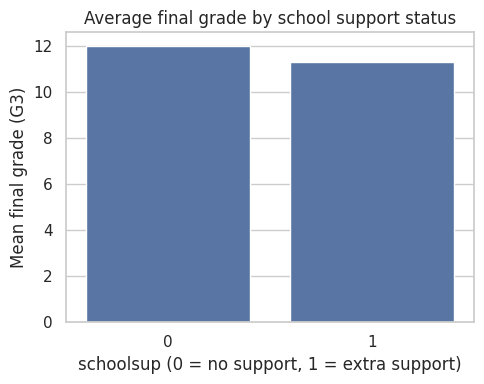

In [3]:
# 3.1 Load and clean data

df_raw = load_student_data(source="ucimlrepo")
df = clean_student_data(df_raw)

print(f"Dataset shape: {df.shape}")
df.head()

# 3.2 Build default configuration and summarize treatment

config = make_default_config()
config

treatment_summary = summarize_treatment(df, config)
treatment_summary

plt.figure(figsize=(5, 4))
sns.barplot(data=treatment_summary, x="treatment", y="mean_outcome")
plt.xlabel("schoolsup (0 = no support, 1 = extra support)")
plt.ylabel("Mean final grade (G3)")
plt.title("Average final grade by school support status")
plt.tight_layout()
plt.show()

In [4]:
# 3.3 Fit LinearDML via the wrapper

config.estimator_type = "linear_dml"
linear_model = fit_econml_estimator(df, config)

linear_ate = estimate_ate(linear_model, df, config)
linear_ate

{'ate': 0.015329032419103612,
 'ate_ci_lower': -0.3644693841207609,
 'ate_ci_upper': 0.3951274489589682}

### 3.4 Interpretation of LinearDML ATE

The `linear_ate` dictionary reports:

- `ate`: the estimated **average treatment effect** of the school support program (`schoolsup`) on the final grade `G3`, after adjusting for confounders (e.g., prior grades `G1`, `G2`, and other covariates).
- `ate_ci_lower`, `ate_ci_upper`: a 95% confidence interval for the ATE.

Because this is a **linear CATE model**, we can interpret this as the average change in `G3` (in grade points) associated with participation in the support program, holding observed covariates fixed.

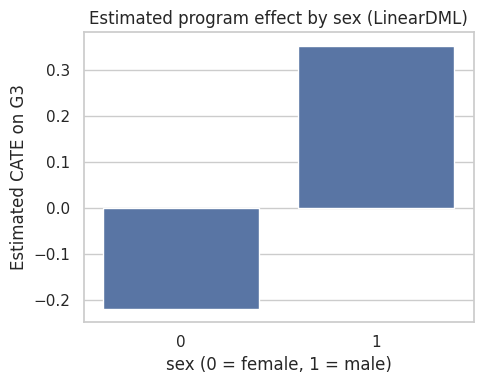

In [5]:
# 3.5 Heterogeneous effects by subgroup

# Estimated Conditional Average Treatment Effects by Sex (LinearDML)
cate_by_sex_linear = estimate_cate_by_subgroup(
    linear_model,
    df,
    config,
    subgroup_col="sex",  # 0 = female, 1 = male
)
cate_by_sex_linear

plt.figure(figsize=(5, 4))
sns.barplot(data=cate_by_sex_linear, x="subgroup", y="cate_mean")
plt.xlabel("sex (0 = female, 1 = male)")
plt.ylabel("Estimated CATE on G3")
plt.title("Estimated program effect by sex (LinearDML)")
plt.tight_layout()
plt.show()

In [6]:
# 3.6 Switch to CausalForestDML (non-linear heterogeneity)

config.estimator_type = "causal_forest"
forest_model = fit_econml_estimator(df, config)

# Estimated Average Treatment Effect (CausalForestDML)
forest_ate = estimate_ate(forest_model, df, config)
forest_ate

{'ate': 0.04074594532856175,
 'ate_ci_lower': -1.0113610584092294,
 'ate_ci_upper': 1.0928529490663526}

In [7]:
# Estimated Conditional Average Treatment Effects by Sex (CausalForestDML)
cate_by_sex_forest = estimate_cate_by_subgroup(
    forest_model,
    df,
    config,
    subgroup_col="sex",
)
cate_by_sex_forest

,subgroup,cate_mean,cate_std,n
0,0,0.020157,0.400552,383
1,1,0.070391,0.446682,266


In [8]:
# 3.7 Switch to SparseLinearDML (sparse linear CATE)
config.estimator_type = "sparse_linear_dml"
sparse_model = fit_econml_estimator(df, config)

# Estimated Average Treatment Effect (SparseLinearDML)
sparse_ate = estimate_ate(sparse_model, df, config)
sparse_ate

{'ate': -2.650475027303629,
 'ate_ci_lower': -5.217775939609061,
 'ate_ci_upper': -0.08317411499819682}

In [9]:
# Estimated Conditional Average Treatment Effects by Mother's Education Level (CausalForestDML)
cate_by_medu_sparse = estimate_cate_by_subgroup(
    sparse_model,
    df,
    config,
    subgroup_col="Medu",
)
cate_by_medu_sparse.head()

,subgroup,cate_mean,cate_std,n
0,0,-1.572010,1.065036,6
1,1,-1.994244,0.878136,143
2,2,-2.561382,0.734953,186
3,3,-2.786274,0.839279,139
4,4,-3.210515,0.540173,175
